# 2950 Project: Airplane Fares Over Time  (Phase IV)
By Anderson Ramirez (ar2527), Cian Llerena (cl2632), Sophia Escalante (sae85), Will Biloski (wb292)

## *Table of Contents*
1. [Introduction](#Introduction)
2. [Data Description](#data-description)
3. [Preregistration Statement](#preregistration-statement)
4. [Data Analysis](#data-analysis)
5. [Evaluation of Significance](#evaluation-of-significance)
6. [Conclusion](#conclusion)
7. [Acknowledgements and Bibliography](#acknowledgements-and-bibliography)


# Introduction 

With this project we looked to evaluate how various factors can effect the price of airfare in domestic flights in the United States during 1993 and 2024. The factors we analyzed from our dataset were passenger volume and time allowing us to get insight into how fares have changed due to inflation, holiday seasons, and passenger surges at peak travel times. 



This effects everyone since air travel has been a consistently growing industry since its inception. Each day more and more people travel by air for various reasons such as work, family visits, and vacation. This surge in air travel has led an evergrowing number of people to be impacted by changes in airfare. Even slight increases in these fares can create huge barriers, potentially preventing people from visiting family or going to work. This has led us to look into inflation and fares over time to see how airfare has changed and impacted families across the United States. 

#### Main Question: 
Which factors have the greatest affect on airline fares?
#### Sub Questions: 
1. How does airfare change as flight distance increases? Are shorter flights more expensive per mile than longer ones?
2. Is there a relationship between passenger count and average fare (for example, do more popular routes tend to have lower fares due to competition)?


## **Data Sources**
#### **1.) US Airline Flight Routes and Fares 1993–2024:**
Where and What this dataset:
- *US Airline Flight Routes and Fares 1993–2024*, provided by the Bureau of Transportation Statistics (BTS).  
- Available on Kaggle: [US Airline Flight Routes and Fares Dataset](https://www.kaggle.com/datasets/bhavikjikadara/us-airline-flight-routes-and-fares-1993-2024)

Why this dataset:
- It provides detailed fare and passenger data for thousands of U.S. flight routes over time, allowing us to explore how distance, competition, and market structure influence airfare pricing.


#### **2.) Inflation, consumer prices (annual %):**
Where and What this dataset:
- *Inflation, consumer prices (annual %)*, provided by the World Bank for Data.
- Available from World Bank Data: [Inflation, consumer prices (annual %)](https://data.worldbank.org/indicator/FP.CPI.TOTL.ZG)

Why this dataset:
- It provides annual data from 1960 to 2024 of global inflation rates (annual inflation rates), and had complete data for the United States, allowing us to calculate the Consumer Price Indices (CPI) from 1993 to 2024, and thus track and account for inflation throughout this timeline.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt


## **Data Cleaning**

#### **How We Loaded in the Dataset: *US Airline Flight Routes and Fares 1993-2024.csv***
**Map of data and loading in CSV file:**\
Our dataset is very large, existing with an original 245955 rows and 23 columns. Due to this, our dataset was taking up an enormous amount of space and processing time. In order to reduce this, we essentially created a map of each column's expected datatype, as to prevent pandas needing to infer the data type per column. This saves space while loading in the dataset, and also allows it to load quicker.

In [2]:
dtype_map = {
    "tbl": "object",
    "Year": "int64",
    "quarter": "int64",
    "citymarketid_1": "int64",
    "citymarketid_2": "int64",
    "city1": "object",
    "city2": "object",
    "airportid_1": "int64",
    "airportid_2": "int64",
    "airport_1": "object",
    "airport_2": "object",
    "nsmiles": "int64",
    "passengers": "int64",
    "fare": "float64",
    "carrier_lg": "object",
    "large_ms": "float64",
    "fare_lg": "float64",
    "carrier_low": "object",
    "fare_low": "float64",
    "Geocoded_City1": "object",
    "Geocoded_City2": "object",
    "tbl1apk": "object"
}

flight_df = pd.read_csv(
    'US Airline Flight Routes and Fares 1993-2024.csv', 
    dtype=dtype_map)

print(flight_df.shape)
flight_df.info()
flight_df.head()

(245955, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245955 entries, 0 to 245954
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tbl             245955 non-null  object 
 1   Year            245955 non-null  int64  
 2   quarter         245955 non-null  int64  
 3   citymarketid_1  245955 non-null  int64  
 4   citymarketid_2  245955 non-null  int64  
 5   city1           245955 non-null  object 
 6   city2           245955 non-null  object 
 7   airportid_1     245955 non-null  int64  
 8   airportid_2     245955 non-null  int64  
 9   airport_1       245955 non-null  object 
 10  airport_2       245955 non-null  object 
 11  nsmiles         245955 non-null  int64  
 12  passengers      245955 non-null  int64  
 13  fare            245955 non-null  float64
 14  carrier_lg      244415 non-null  object 
 15  large_ms        244415 non-null  float64
 16  fare_lg         244415 non-null  float64
 1

,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


**Finding Missing Values:**\
While we know that missing values can be handled by a NaN value, it is always better to not have them. These missing values can cause errors in our statistical analysis, especially in a machine learning model

In [3]:
missing_values_per_column = flight_df.isnull().sum()
print(missing_values_per_column)

tbl                   0
Year                  0
quarter               0
citymarketid_1        0
citymarketid_2        0
city1                 0
city2                 0
airportid_1           0
airportid_2           0
airport_1             0
airport_2             0
nsmiles               0
passengers            0
fare                  0
carrier_lg         1540
large_ms           1540
fare_lg            1540
carrier_low        1612
lf_ms              1612
fare_low           1612
Geocoded_City1    39206
Geocoded_City2    39206
tbl1apk               0
dtype: int64


**Dropping Unnecessary Columns for the *flight_df*:**\
Within this dataset, several columns contain identifiers or redundant information that are not relevant to our analysis. Since our research focuses on how distance, passenger volume, and carrier type affect airfare, we will remove columns that do not contribute to those variables.

We are dropping:
- tbl: table label not needed for analysis
- citymarketid_1, citymarketid_2: internal market identifiers
- airportid_1, airportid_2: duplicate information since we are keeping airport codes instead
- Geocoded_City1, Geocoded_City2: geocoded fields with redundant data

These columns do not give insight into airfare patterns and will be removed to simplify the dataset.


In [4]:
flight_df = flight_df.drop(
    ['tbl', 'airportid_1',
     'airportid_2',
     'citymarketid_1',
     'citymarketid_2',
     'Geocoded_City1',
     'Geocoded_City2',
     'tbl1apk'],
    axis=1)
flight_df = flight_df.drop(
    ['carrier_lg',
      'large_ms',
        'fare_lg',
          'carrier_low',
            'lf_ms',
              'fare_low'],
      axis=1)
flight_df.head()

,Year,quarter,city1,city2,airport_1,airport_2,nsmiles,passengers,fare
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",ABE,PIE,970,180,81.43
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",ABE,TPA,970,19,208.93
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",ABQ,DAL,580,204,184.56
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",ABQ,DFW,580,264,182.64
4,2021,3,"Albuquerque, NM","Phoenix, AZ",ABQ,PHX,328,398,177.11


We check again to make sure we have no missing values.

In [5]:
missing_values_per_column = flight_df.isnull().sum()
print(missing_values_per_column)

Year          0
quarter       0
city1         0
city2         0
airport_1     0
airport_2     0
nsmiles       0
passengers    0
fare          0
dtype: int64


#### **How we loaded in the Dataset: *CPI_data - Sheet1.csv***
This data represents the *Consumer Price Index (CPI)* per year from 1960 to 2024 for most countries; however, we will clean the data to contain only the CPI data from 1993 to 2024 for the United States. Since this data frame is relatively small- in comparison to our *flights_df*-we are able to load it in as a regular data frame using pandas.

**Loading in the CPI csv file:**

In [6]:
cpi_per_year_df = pd.read_csv('CPI_data - Sheet1 .csv')

print('This is the shape of cpi_per_year_df: ' 
      + str(cpi_per_year_df.shape))
cpi_per_year_df.head()

This is the shape of cpi_per_year_df: (266, 69)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,0.474764,-0.931196,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,5.245878,6.596505,6.399343,4.720805,4.644967,5.405162,7.240978,10.773751,7.126975,4.425471
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.661709,4.383892,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,2.130817,1.487416,1.725486,1.784050,1.983092,2.490378,3.745568,7.930929,5.489286,3.615966
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,9.355972,30.694415,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495


**Selecting United States Data:**\
Here we are selecting only the row with United States data from the *cpi_per_year_df*, and saving it as *cpi_per_year_us*.

In [7]:
# This data is a series now, since it is only one row
cpi_per_year_us = cpi_per_year_df.iloc[251] 

print('This is the shape of cpi_per_year_us: ' +
       str(cpi_per_year_us.shape))
print(cpi_per_year_us)

This is the shape of cpi_per_year_us: (69,)
Country Name                              United States
Country Code                                        USA
Indicator Name    Inflation, consumer prices (annual %)
Indicator Code                           FP.CPI.TOTL.ZG
1960                                           1.457976
                                  ...                  
2020                                           1.233584
2021                                           4.697859
2022                                             8.0028
2023                                           4.116338
2024                                           2.949525
Name: 251, Length: 69, dtype: object


**Finding Missing Values:**\
While we know that missing values can be handled by a NaN value, it is always better to not have them. These missing values can cause errors in our statistical analysis, especially in a machine learning model

*Please note that we only have a series, so we are only checking one row of data*

In [8]:
missing_values = cpi_per_year_us.isnull().sum()
print(missing_values)

0


**Dropping columns:**

 Now we are dropping the columns we do not need from *cpi_per_year_us*:
- *Country Name*: We do not need this as it is assumed our scope is only referring to United States Data
- *Country Code*: We do not need this because our scope is only United States data
- *Indicator Name*: We do not need this because our scope is only United States data
- *Indicator Code*: We do not need this because our scope is only United States data
- *Years from 1960 to 1992 inclusive*: We do not need to analyze data prior to 1993.

In [9]:
years_to_drop = np.arange(1960, 1993).astype(str)
cpi_per_year_us = cpi_per_year_us.drop(years_to_drop)
cpi_per_year_us = cpi_per_year_us.drop(
    ['Country Name',
      'Country Code',
        'Indicator Name',
          'Indicator Code',])

print(
    'This is the shape of cpi_per_year_us after dropping uneeded columns: ' 
    + str(cpi_per_year_us.shape))

This is the shape of cpi_per_year_us after dropping uneeded columns: (32,)


**Ediding cpi_per_year_us:**

Here we are editing *cpi_per_year_us* to become a data frame rather than a series. In this process, *cpi_per_year_us* is melted, and so we also add appropriate column titles by resetting the idices, and thus adding the titles we want.

In [10]:
cpi_per_year_us_df = cpi_per_year_us.to_frame()
cpi_per_year_us_df = cpi_per_year_us_df.reset_index()
cpi_per_year_us_df.columns = ['Year', 'CPI_per_year']
cpi_per_year_us_df['CPI_per_year'] = cpi_per_year_us_df['CPI_per_year']

print(
    'This is the shape of cpi_per_year_us after dropping uneeded columns: '
      + str(cpi_per_year_us.shape))
cpi_per_year_us_df.head()

#print(cpi_per_year_us_df)

This is the shape of cpi_per_year_us after dropping uneeded columns: (32,)


,Year,CPI_per_year
0,1993,2.951657
1,1994,2.607442
2,1995,2.80542
3,1996,2.931204
4,1997,2.33769


**Converting column data:**

Next, we must convert our column data types to be what we expect.
- Year --> int
- CPI_per_year --> float

In [11]:
cpi_per_year_us_df['Year'] = cpi_per_year_us_df['Year'].astype(int)
cpi_per_year_us_df['CPI_per_year'] = cpi_per_year_us_df[
    'CPI_per_year'].astype(float)

print('Columns names \'Year\' data type: ' + 
      str(cpi_per_year_us_df['Year'].dtype))
print('Columns names \'CPI_per_year\' data type: ' + 
      str(cpi_per_year_us_df['CPI_per_year'].dtype))

Columns names 'Year' data type: int64
Columns names 'CPI_per_year' data type: float64


**Currently, our columns *CPI_per_year* represents the annual inflation rate per year. We must take these values and convert it into the CPI rate from 1993 to 2024; this way, we can scale the costs to be in terms of nominal value in 2024 (what we consider our present day). We calculate this by doing the following:**

We set the base **Consumer Price Index (CPI) to be 2024 and thus CPI = 100**.
After setting the base as 2024 (CPI = 100), we can calculate the CPI for the years prior 2024 using the fomrula:

 ***CPI<sub>target_year</sub> = CPI<sub>prior_year</sub> * (1 + (inflation_rate<sub>current_year</sub> / 100))***

In [12]:

cpi_per_year_us_df.sort_values(by='Year', inplace=True)

multiply_by = 1 + (cpi_per_year_us_df['CPI_per_year'] / 100)

base_year = 1993
base_year_index = cpi_per_year_us_df[cpi_per_year_us_df[
    'Year'] == base_year]\
.index[0]

multiply_by.loc[base_year_index] = 1.0

cumulative_index = multiply_by.cumprod() * 100

cpi_per_year_us_df['CPI_per_year'] = cumulative_index

#Ensuring our changes worked
print("DataFrame after replacing rates with the index:")
print(cpi_per_year_us_df.head())


DataFrame after replacing rates with the index:
   Year  CPI_per_year
0  1993    100.000000
1  1994    102.607442
2  1995    105.486011
3  1996    108.578021
4  1997    111.116239


#### **Merging *flights_df* with *cpi_per_year_us_df* by *Year***
Here we are creating a **new** data frame to represent our *flights_df* with the addition of *cpi_per_year_us_df* per corresponding year. We Will do this through an **inner merge** on *flights_df* and *cpi_per_year_us_df* by year.

In [13]:
flights_and_inflation_df = pd.merge(flight_df, cpi_per_year_us_df,
                                     on='Year', how='inner')
flights_and_inflation_df.head()

,Year,quarter,city1,city2,airport_1,airport_2,nsmiles,passengers,fare,CPI_per_year
0,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",ABE,PIE,970,180,81.43,187.576406
1,2021,3,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",ABE,TPA,970,19,208.93,187.576406
2,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",ABQ,DAL,580,204,184.56,187.576406
3,2021,3,"Albuquerque, NM","Dallas/Fort Worth, TX",ABQ,DFW,580,264,182.64,187.576406
4,2021,3,"Albuquerque, NM","Phoenix, AZ",ABQ,PHX,328,398,177.11,187.576406


**Finding Missing Values:**\
For good practice, we will ensure there are no missing values in our dataset after this merge, to preserve our data usability.  

In [14]:
missing_values_after_merge = flights_and_inflation_df.isnull().sum()
print(missing_values_after_merge)

Year            0
quarter         0
city1           0
city2           0
airport_1       0
airport_2       0
nsmiles         0
passengers      0
fare            0
CPI_per_year    0
dtype: int64


## **Exploratory data analysis (EDA)**

### **How Fare is Affected by Flight Distance**

**Cleaning data for fare by distance**

In [15]:
distance_trends = flight_df[["fare", "nsmiles"]].dropna()

# Drop invalid rows
distance_trends = distance_trends[(distance_trends[
    "fare"] > 0) & (distance_trends["nsmiles"] > 0)]

distance_trends.head()


,fare,nsmiles
0,81.43,970
1,208.93,970
2,184.56,580
3,182.64,580
4,177.11,328


**Fitting a trend line to this data**

In [16]:
X = distance_trends[["nsmiles"]]
y = distance_trends["fare"]

dist_model = LinearRegression()
dist_model.fit(X, y)
y_pred = dist_model.predict(X)

# Predictions and metrics
print(f"Intercept: {np.round(dist_model.intercept_, 2)}")
print(f"Coefficient: {np.round(dist_model.coef_[0], 4)}")

Intercept: 149.23
Coefficient: 0.0586


**Lets further analyze this trend**\
To do so we will calculate the correlation between the flight distance and the fare value. Then since we have performed a linear fit of the data we wil see how well this represents the data by determining the R^2 value

In [17]:
dist_corr = distance_trends["fare"].corr(distance_trends["nsmiles"])
print(f"Fare correlation to distance: {dist_corr}")
r2 = np.round(dist_model.score(X, y), 4)
print(f"R-squared: {r2}")



Fare correlation to distance: 0.5004065012945056
R-squared: 0.2504


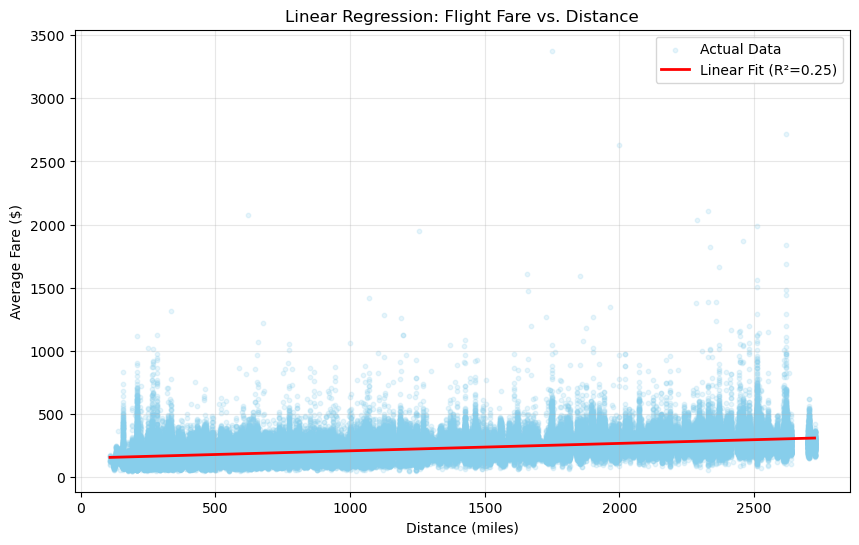

In [18]:
plt.figure(figsize=(10,6))

# Scatter plot of the data
plt.scatter(X, y, color="skyblue", alpha=0.2, s=10, label="Actual Data")

# Sort X for a smooth line
sort_idx = np.argsort(X.values.flatten())
plt.plot(X.values.flatten()[sort_idx], y_pred[sort_idx], color="red",
          linewidth=2,
         label=f"Linear Fit (R²={r2:.2f})")

# Labels and title
plt.title("Linear Regression: Flight Fare vs. Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Average Fare ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Explanation of correlation and R-squared**\
Here the correlation is roughly 0.5. This tells us that there is a moderately positive relationship between flight distance and fare, meaning as distance increases there is also a general increase in fare.

Our R-squared value is 0.25. This tells us that flight distance is responsible for around 25% of the variance in the fares.


**graphing fare vs quarter**\
With this data set we want to look at how certain quarters with many holidays (such as quarter one and four) have differing airline fare prices when compared to those without many holidays. We grouped by quarters in order to allow us to access the average fare per quarter for every year and average them.

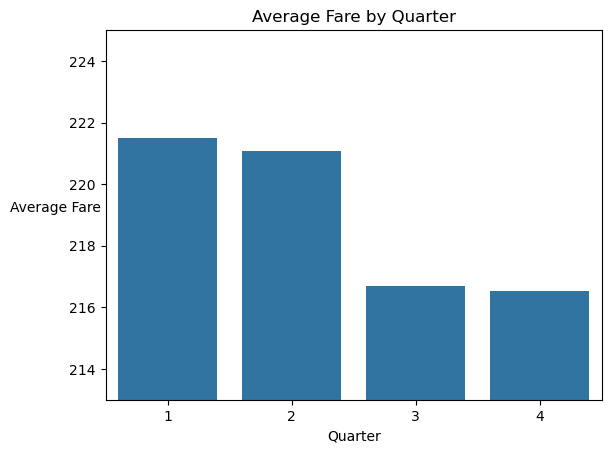

In [19]:
fare_quarter_df = duckdb.sql("""
                             SELECT AVG(fare) AS average_fare, 
                             quarter FROM flight_df 
                             GROUP BY quarter""").df()
sns.barplot(data = fare_quarter_df, x = "quarter", y = "average_fare")
plt.ylim(213, 225)

plt.title("Average Fare by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Fare", rotation = 0,labelpad = 10);

**Findings**\
This graph demonstrates that airlines increase the prices for flights during the start of the year (the first and second quarters). This is vastly different than what we expected since we predicted that the fourth quarter would have the highest fares. This is very unexpected for us since we figured holidays like christmas, thanksgiving and new years would increase travel rates and fares. The data clearly does not support this claim since the first half of the year has the most costly airline tickets.

### **Time series (Fare over time) 1993 - 2024**
*Formula to account for inflation: Adjusted Value = Nominal Value * (CPI\_Current / CPI\_BaseYear)*


In [20]:
base_cpi = cpi_per_year_us_df.loc[
    cpi_per_year_us_df['Year'] == 2024, \
                                  'CPI_per_year'].iloc[
                                      0] # 2024 is the base CPI

year_to_cpi_map = cpi_per_year_us_df.set_index('Year')['CPI_per_year']

og_year_cpi = flights_and_inflation_df['Year'].map(year_to_cpi_map)

flights_and_inflation_df['fare_with_inflation'] = \
    flights_and_inflation_df['fare'] * (base_cpi / og_year_cpi)

print('Shape of flights_and_inflation_df: ' + \
      str(flights_and_inflation_df.shape))
print(flights_and_inflation_df[
    ['Year', 'fare', 'fare_with_inflation']].head())
print('\n')

##create mini df for time series graphing
avg_fare_by_year_inflation = flights_and_inflation_df\
.groupby('Year')[['fare', 'fare_with_inflation']].mean().reset_index()

nominal_value = flights_and_inflation_df['fare']
cpi_current = flights_and_inflation_df['CPI_per_year']
cpi_base_year = cpi_per_year_us_df.loc[cpi_per_year_us_df['Year'] == 2024]

flights_and_inflation_df['fare_with_inflation'] = \
nominal_value * (cpi_current / cpi_base_year['CPI_per_year'])

print('Shape of avg_fare_by_year_inflation: ' + \
      str(avg_fare_by_year_inflation.shape))
print(avg_fare_by_year_inflation.head())

Shape of flights_and_inflation_df: (245955, 11)
   Year    fare  fare_with_inflation
0  2021   81.43            94.267651
1  2021  208.93           241.868356
2  2021  184.56           213.656362
3  2021  182.64           211.433669
4  2021  177.11           205.031851


Shape of avg_fare_by_year_inflation: (31, 3)
   Year        fare  fare_with_inflation
0  1993  214.472632           465.723701
1  1994  217.611944           460.532547
2  1996  204.900283           409.785978
3  1997  208.105858           406.689754
4  1998  210.451983           404.988112


**Plot for Average Fares *WITHOUT* Inflation Adjustments**

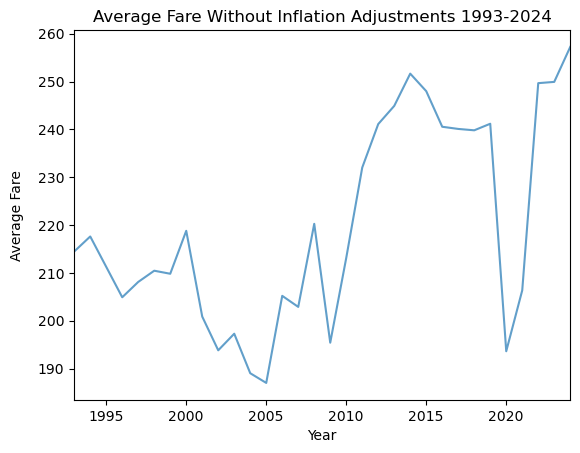

In [21]:
avg_fare_plt = plt.plot(avg_fare_by_year_inflation['Year'], \
                        avg_fare_by_year_inflation['fare'],\
                        label='Nominal Fare', alpha=0.7)

plt.title("Average Fare Without Inflation Adjustments 1993-2024")
plt.xlim(1993, 2024)
plt.xlabel("Year")
plt.ylabel("Average Fare", rotation = 90,labelpad = 10);

**Interpretation of Average Fare Over Time (NOT Adjusted for Inflation):**

The plot shows that average airline fares **(without inflation adjustment)** have generally risen from 1993 to 2024. We can see sharp drops in this trend corresponding to major crises: the period following the 9/11 attacks (2001-2003), the 2008-2010 financial crisis, and the 2020 COVID-19 pandemic.

We can also see prices rise again after the 2001, 2008, and 2020 drops. This represents a recovery in passenger demand, a pattern typical of the airline industry's response to recessions and external shocks. Regardless, the graph shows prices being the highest in 2024, representing a significant increase in the nominal cost of air travel since 1993.

**Plot for Average Fares *WITH* Inflation Adjustments**

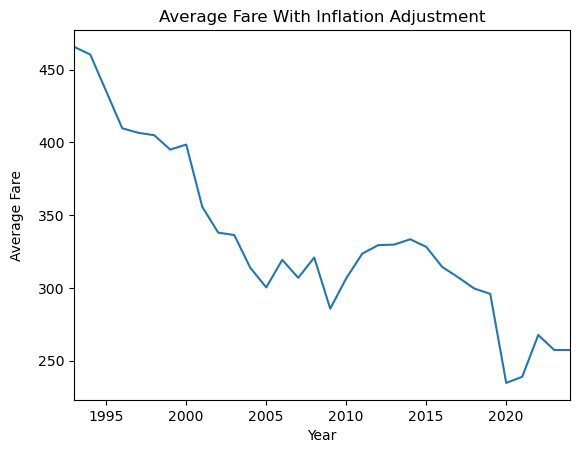

In [22]:
avg_fare_inflation_plt = plt.plot(
    avg_fare_by_year_inflation['Year'],
      avg_fare_by_year_inflation['fare_with_inflation'],
        label='Fare with Inflation Adjustment')

plt.title("Average Fare With Inflation Adjustment")
plt.xlim(1993, 2024)
plt.xlabel("Year")
plt.ylabel("Average Fare", rotation = 90,labelpad = 10);


**Interpretation of Average Fare over Time (Adjusted for Inflation):** \
The plot shows that average airline fares **(with inflation adjustments)** have significantly fallen from 1993 to 2024. We can still see sharp drops in this trend corresponding to major crises: the period following the 9/11 attacks (2001-2003), the 2008-2010 financial crisis, and the 2020 COVID-19 pandemic.

We can also see prices rise again after the 2001, 2008, and 2020 drops. This represents a recovery in passenger demand, a pattern typical of the airline industry's response to recessions and external shocks. Regardless, the graph shows prices are the lowest in 2024, representing a significant decrease in the nominal cost of air travel since 1993.

**Why Adjusting for Inflation is Important:**\
One of the most important findings from this comparison is realizing that according to our data, prices for flights since 1993 have **NOT** increased drastcially, but in fact **have decreased** signifcantly. Accounting for inflation is critical in this analysis, as it depicts the changes in purchasing power of the United States Dollar, and reveals that average fare of flights has overall decreased.

### **Passenger Volume vs. Fare**

**Passenger Volume vs. Fare**

In this section, we want to see how the number of passengers on a flight route relates to the average fare. Our assumption is that routes with more passengers (higher demand) might have lower fares due to increased competition, or higher fares if demand outpaces supply.

In [23]:
pvf_df = flight_df

pvf_df[['passengers', 'fare']].describe()

,passengers,fare
count,245955.000000,245955.000000
mean,299.476795,218.979587
std,511.389486,82.372486
min,0.000000,50.000000
25%,21.000000,164.620000
50%,113.000000,209.320000
75%,339.000000,262.890000
max,8301.000000,3377.000000


This gives us an overview of the distribution of passenger volumes and fare prices across routes.

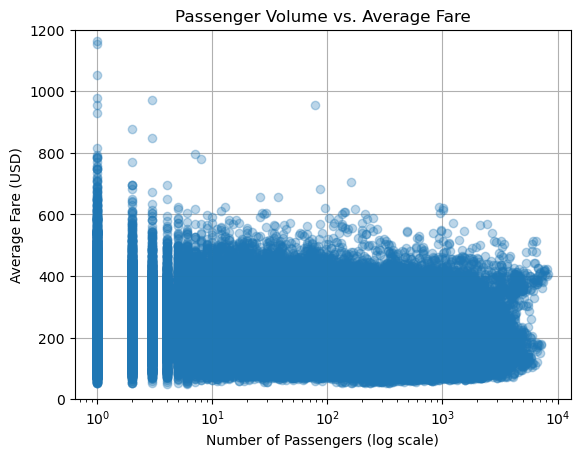

In [24]:
plt.plot(pvf_df["passengers"], pvf_df["fare"], "o", alpha=0.3)
plt.xscale("log")
plt.xlabel("Number of Passengers (log scale)")
plt.ylim(0, 1200)
plt.ylabel("Average Fare (USD)")
plt.title("Passenger Volume vs. Average Fare")
plt.grid(True)
plt.show()

In this scatterplot, I added a alogarithmic scale on the x-axis using plt.xscale("log") because passenger counts depends on some different factors such as routes having only a few hundred passengers, while others have millions. The log scale makes the large values compress and spreads out smaller ones, letting all the routes be visualized together on the same plot. I also set alpha=0.3 to make overlapping points more transparent, which helps show areas of higher density, and limited the y-axis (plt.ylim(0, 1200)) so that extreme outliers don’t distort the visible range of typical fares.

**Interpretation of the Plot**

This scatter plot visualizes how the number of passengers (x-axis) relates to the average airfare (y-axis).
- Routes with few passengers (on the left side of the plot) show higher and more variable fares, showing limited service or low competition (like the Ithaca airport for example).
- Routes with alot of passengers (toward the right) have lower and more stable fares, probaly because of stronger competition and higher seat capacity.

Overall, there seems to be a slight negative relationship between passenger volume and fare, because as passenger counts increase, average fares tend to decrease and become more consistent. This supports our hypothesis that greater market demand and competition can drive down prices on busy routes.

In [25]:
pvf_df[['passengers', 'fare']] = pvf_df[['passengers', 'fare']].dropna()

X = pvf_df[['passengers']]
y = pvf_df['fare']

pvf_model = LinearRegression().fit(X, y)

print(f"Intercept: {np.round(pvf_model.intercept_, 2)}")
print(f"Coefficient: {np.round(pvf_model.coef_[0], 4)}")
print(f"R-squared: {np.round(pvf_model.score(X, y), 4)}")

Intercept: 227.25
Coefficient: -0.0276
R-squared: 0.0294


**Interpretation of the Regression**

The regression model results show a negative relationship between passengers and average airfare. The model intercept of $227.25 shows the predicted fare when passengers are zero. The coefficient of -0.0276 shows that for every additional passenger on a route, the fare decreases by approximately 2.8 cents. While 2.8 cents has a small effect, the negative sign supports the hypothesis that routes with higher passengers have lower fares, because of increased competition on busy routes. The model’s R-squared value of 0.0294 means passengers alone explain about 3% of the variation in average fares. This shows that while passenger have a measurable influence, other variables like distance, carrier type, and etc, have a bigger role in calculating airfare prices. There is evidence of a weak but consistent inverse relationship between passenger count and airfare.

## **Data Description**

### Data Description: **US Airline Flight Routes and Fares 1960–2024 - Kaggle**



**What Does Each Row Represent:**\
Each instance in this data frame is a unique flight route in a specific quarter for a specific year. Each row includes data about the average fares, route distance, and other data.


**Why Was This Dataset Created:**\
This dataset was created to allow insight into things such as travel statistics, price metrics of flights and other travel related information


**Who Funded the Creation of the Dataset:**\
The dataset was created by a student who gathered federally funded data from the Bureau of Transportation.


**What Processes Might Have Influenced What Data was Observed and Recorded and What was Not:**\
The size of the airport and route effect what data was included since smaller local airports are not included in the dataset


**What Preprocessing Was Done, and How Did the Data come to be in the Form That You Are Using:**\
The data was scrapped and converted into a usable dataframe on kaggle.


**If People are Involved, Were They Aware of the Data Collection and if so, What Purpose Did They Txpect the Data To Be Used For:**\
The passengers are not directly involved in the data collection but they do indirectly consent to their data being gathered when traveling by air.


**Where Can Your Raw Source Data be Found, if Applicable? Provide a link to the raw data:**\
This data was gathered from the Bureau of Transportation. https://www.transtats.bts.gov/DatabaseInfo.asp?QO_VQ=EFI&Yv0x=D



**Columns:**
- ​Year: year that the flight route occurred
- Quarter: quarter the flight route occurred
- City1: origin city
- City2: destination city
- Airport_1: origin airport code
- Airport_2: destination airport code
- Nsmiles: length of flight in miles
- Passengers: number of passengers that traveled on a specific flight route in a specific quarter
- Fare: average fare paid by passengers in on a specific flight route in a specific quarter
- Carrier_lg: Airline with the most passengers in a quarter flying any specific route
- Large_ms: Largest airlines market share
- Fare_lg: Average fare paid by passengers for those flying with the largest airline for that route
- Carrier_low: code for airline with cheapest fare on that route
- Lf_ms: market share for the cheapest airline on that route
- Fare_low: lowest fare


### Data Description: **Inflation, consumer prices (annual %) - United States - World Bank Group Data**

**What Does Each Row Represent:**\
Each instance in this data frame is a unique country.


**Why Was This Dataset Created:**\
This dataset was created to allow insight into the inflation rates of various countries in the world. There are various countries that have NaN values, due to data not being able to be collected; however, for the United States, there is complete data from 1960 to 2024.


**Who Funded the Creation of the Dataset:**\
The dataset was founded by the *International Financial Statistics database, International Monetary Fund ( IMF )* and the *contributers of World Bank Data* to be able to visualize the trend of inflation rates over years.

**What Processes Might Have Influenced What Data was Observed and Recorded and What was Not:**\
For the scope of the United States, we had complete data for inflation rates over time, so there was no lapse of data being recorded. However, major factors definitely could have influenced the data; such as the *financial crisis of 2008* and the *COVID-19 Pandemic in 2020*.


**What Preprocessing Was Done, and How Did the Data come to be in the Form That You Are Using:**\
The data was observed over lived experience, and collected by comparing the Consumer Index Price from the current year to past years. It was put together by International Financial Statistics database, International Monetary Fund ( IMF ) by using government reports for CPI collection.


**If People are Involved, Were They Aware of the Data Collection and if so, What Purpose Did They Txpect the Data To Be Used For:**\
N/A

**Where Can Your Raw Source Data be Found, if Applicable? Provide a link to the raw data:**\
This data was gathered from the Bureau of Transportation. https://data.worldbank.org/indicator/FP.CPI.TOTL.ZG



**Columns:**
- Country Name: Name of the country observed
- Country Code: Code of the country observed\
  *(Ex. United States = U.S)*
- Indicator Name: What we are observing -\
 *Inflation, consumer prices (annual %)*
- Indicator Code: Dataset we are using - *FP.CPI.TOTL.ZG*
- Years from 1960 - 2024 (inclusive): Observed annual inflation rate to calcualte CPI Index from a given base year

## **Data Limitations**

Our dataset has a strong focus towards large airports in larger cities and excludes smaller regional airports. This causes underrepresentation for shorter routes by miles since smaller airports typically operate on shorter flights. These shorter flights are disproportionately expensive per mile as these smaller airports have to handle their fixed costs with less volume of flights. By excluding these flights, we are understating the average cost per mile for short flights. This would affect our regression model for fare by distance since it might suggest that distance explains less variation than it does in the full market.

This exclusion of smaller regional airports has other effects on our analysis as well.  Smaller airports rely more on seasonal flights rather than business and year round travel like larger airports. This means that our data is missing strong seasonal shifts such as Summer surges and Winter dips. This can have an effect on our analysis of the different quarters on airline fares. Without the Summer surge from smaller airports we are understating the overall average fare during quarter 3, and without the Winter dip we are not properly representing the average fare for quarter 4. This means our overall analysis of the pricing per quarter can be misleading since we aren’t including the full market of flights.


## **Questions for Reviewers**
- Is our analysis considered complex enough for this project?
- Is the description of our data clear and understandable from an outside perspective?
- Is our document organized and easy to follow along with?
- Do you understand our headers, subheaders, and sometimes their descriptions?
- Any advice on how to improve our project for a great grade for the final product?
